## Setup

Edit config for target dataset as well as labeled sequences

In [41]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from collections import namedtuple

class DSConfig(namedtuple("DSConfig", ["path", "name"])):
    pass

DATASETS_MAP = {
    "confirmed": DSConfig(
        path="data/proteomes/confirmed_candidates/", 
        name="Confirmed Candidates [n=1,074]"
    ),
    "in-silico": DSConfig(
        path="data/proteomes/gnn_predictions/", 
        name="In-Silico Candidates [n=465,872]"
    ),
    "MAPP": DSConfig(
        path="data/test/mass_spec_dedup/",
        name="MAPP Candidates [n=50,251]"
    ),
}

# Config for determining dataset to use.
DATASET = "MAPP"

CONFIG = DATASETS_MAP[DATASET]
# Combined output produced by run_model_inference.py.
# Relative paths resolve from this notebook or the repository root.
MODEL_COMPARISON_RESULT = (
    f"../sequence_to_svm_minimal/{CONFIG.path}"
    "generated/model_comparison_latest.csv"
)

# Displayed at the beginning of every chart title.
DATASET_NAME = CONFIG.name

# sequence -> plot label; matching ignores case and surrounding whitespace.
HIGHLIGHTED_SEQUENCES = {
    # "SLVTKKKRFWCWQRPKYQFL": "DFNA5",
    "SLVTKKKRFWCWQRPKYQFL": "DFNA5",
    "SQLYPRHKHLLIKRSLRCRKC": "DCTN4",
    "MRAKWRKKRMRRLK": "RPL41",
    "RSIFIKYKSKPFCEKLLSWVKS": "PSMG2",
    "SRVPRFYWKDRLLKMKMA": "GLB1",
    "LPLIIFLRNRLKY": "RPS4X",
    "KRRFNIKLWKTF": "PPP1CB",
    "RRYVRKFVLMR": "CHMP2A",
    "SRGLRYYYDKNIIHKTAGKRYVYRFV": "ETS1",
    "GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM": "RPS29",
}

PLOT_STYLE = "seaborn-v0_8-whitegrid"
N_BINS = 100
plt.style.use(PLOT_STYLE)
MODEL_COLORS = dict(
    zip(("SVM", "VAE-only"), plt.rcParams["axes.prop_cycle"].by_key()["color"][:2])
)


## Plotting helpers

Safe to ignore after running once to load into notebook

In [42]:
# Plotting helpers


def _normalise_sequence(value):
    if pd.isna(value):
        return ""
    return str(value).strip().upper()


def _highlight_labels():
    if isinstance(HIGHLIGHTED_SEQUENCES, dict):
        items = HIGHLIGHTED_SEQUENCES.items()
    else:
        items = ((sequence, sequence) for sequence in HIGHLIGHTED_SEQUENCES)
    return {
        _normalise_sequence(sequence): str(label)
        for sequence, label in items
        if _normalise_sequence(sequence)
    }


def _resolve_csv_path(value):
    if not str(value).strip():
        raise ValueError("Set MODEL_COMPARISON_RESULT to model_comparison_latest.csv.")

    raw_path = Path(value).expanduser()
    candidates = [raw_path] if raw_path.is_absolute() else [
        Path.cwd() / raw_path,
        Path.cwd() / "notebooks" / raw_path,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(f"Model comparison CSV not found: {raw_path}")


def _find_column(frame, names):
    by_lower = {column.lower(): column for column in frame.columns}
    for name in names:
        if name.lower() in by_lower:
            return by_lower[name.lower()]
    return None


def _add_plot_sequence(frame):
    sequence_col = _find_column(frame, ["sequence", "peptide_sequence", "peptide"])
    id_col = _find_column(frame, ["peptide_id", "id"])
    if sequence_col:
        plot_sequence = frame[sequence_col].map(_normalise_sequence)
    elif id_col:
        plot_sequence = frame[id_col].map(_normalise_sequence)
    else:
        plot_sequence = pd.Series("", index=frame.index, dtype="string")
    frame["__plot_sequence"] = plot_sequence


def load_comparison_result():
    csv_path = _resolve_csv_path(MODEL_COMPARISON_RESULT)
    frame = pd.read_csv(csv_path)
    if frame.empty:
        raise ValueError(f"Model comparison CSV is empty: {csv_path}")
    _add_plot_sequence(frame)
    print(f"Loaded {len(frame):,} rows from {csv_path}")

    prob_columns = sorted([c for c in frame.columns if c.endswith("_prob_AMP")])
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    
    # Assign deterministic colors to any newly discovered models
    next_idx = 0
    for col in prob_columns:
        model = _model_from_column(col, "_prob_AMP")
        if model not in MODEL_COLORS:
            # Find the next color not strictly locked to a model, but avoid infinite loops
            loop_start = next_idx
            while palette[next_idx % len(palette)] in MODEL_COLORS.values() and (next_idx - loop_start) < len(palette):
                next_idx += 1
            color = palette[next_idx % len(palette)]
            MODEL_COLORS[model] = color
            next_idx += 1

    return {"path": csv_path, "frame": frame}


def _model_from_column(column, suffix):
    model = column[: -len(suffix)] if suffix and column.endswith(suffix) else column
    return model.strip("_") or column


def _make_entry(dataset, column, suffix, model=None):
    values = pd.to_numeric(dataset["frame"][column], errors="coerce")
    finite = values[np.isfinite(values)]
    if finite.empty:
        return None
    model = model or _model_from_column(column, suffix)
    name = model
    return {
        "name": name,
        "column": column,
        "values": values,
        "finite": finite.to_numpy(dtype=float),
        "frame": dataset["frame"],
    }


def collect_suffix_entries(dataset, suffix):
    entries = []
    for column in dataset["frame"].columns:
        if column.endswith(suffix):
            entry = _make_entry(dataset, column, suffix)
            if entry:
                entries.append(entry)
    return entries


def collect_raw_score_entries(dataset):
    entries = collect_suffix_entries(dataset, "_logit_margin")
    frame = dataset["frame"]
    distance_col = next(
        (column for column in ("SVM_distance", "SVM_hyperplane_distance") if column in frame),
        None,
    )
    if distance_col:
        entry = _make_entry(dataset, distance_col, "_distance", model="SVM")
        if entry:
            entries.append(entry)
    return entries


def highlighted_points(entry):
    labels = _highlight_labels()
    if not labels:
        return []
    sequences = entry["frame"]["__plot_sequence"].map(_normalise_sequence)
    points = []
    for sequence, label in labels.items():
        matches = entry["values"].loc[sequences == sequence].dropna()
        matches = matches[np.isfinite(matches)]
        if not matches.empty:
            points.append((float(matches.iloc[0]), label))
    return points


def report_highlight_matches(dataset):
    requested = set(_highlight_labels())
    if not requested:
        return
    observed = set(dataset["frame"]["__plot_sequence"].map(_normalise_sequence))
    missing = requested - observed
    print(f"Highlighted sequences found: {len(requested) - len(missing)}/{len(requested)}")
    if missing:
        print("Not found:", ", ".join(sorted(missing)))


def distribution_xlim(entries, bounded=None):
    values = np.concatenate([entry["finite"] for entry in entries])
    low, high = np.nanpercentile(values, [1, 99])
    highlighted = [x for entry in entries for x, _ in highlighted_points(entry)]
    if highlighted:
        low = min(low, min(highlighted))
        high = max(high, max(highlighted))
    pad = 0.05 * (high - low) if high > low else 1.0
    limits = (float(low - pad), float(high + pad))
    if bounded:
        limits = (max(bounded[0], limits[0]), min(bounded[1], limits[1]))
    return limits


def _kde_counts(values, xs, bin_width, log_y=False):
    if len(values) < 5 or np.unique(values).size < 2:
        return None
    try:
        density = gaussian_kde(values)(xs) * len(values) * bin_width
    except (np.linalg.LinAlgError, ValueError):
        return None
    return np.maximum(density, 1e-6) if log_y else density


def _annotate_highlights(ax, entries, curves, colors, log_y=False):
    annotation_index = 0
    for entry, color in zip(entries, colors):
        xs, ys = curves.get(entry["name"], (None, None))
        for x_value, label in highlighted_points(entry):
            y_value = float(np.interp(x_value, xs, ys)) if xs is not None else 1.0
            if log_y:
                y_value = max(y_value, 1e-3)
            ax.scatter(x_value, y_value, marker="D", s=34, color=color,
                       edgecolor="white", linewidth=0.5, zorder=5)
            side = -1 if annotation_index % 2 else 1
            tier = annotation_index % 4
            ax.annotate(
                label,
                (x_value, y_value),
                xytext=(side * (8 + 4 * tier), 14 + 9 * tier),
                textcoords="offset points",
                ha="left" if side > 0 else "right",
                fontsize=7,
                color=color,
                arrowprops={"arrowstyle": "-", "color": color, "lw": 0.7},
                zorder=6,
            )
            annotation_index += 1


def _model_colors(entries):
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return [
        MODEL_COLORS.get(entry["name"], palette[index % len(palette)])
        for index, entry in enumerate(entries)
    ]


def draw_distribution(ax, entries, title, xlabel, xlim, threshold=None, log_y=False):
    bins = np.linspace(xlim[0], xlim[1], N_BINS + 1)
    bin_width = bins[1] - bins[0]
    xs = np.linspace(xlim[0], xlim[1], 512)
    colors = _model_colors(entries)
    curves = {}

    for entry, color in zip(entries, colors):
        ax.hist(entry["finite"], bins=bins, color=color, edgecolor=color,
                alpha=0.20, linewidth=0.4, zorder=1)
        density = _kde_counts(entry["finite"], xs, bin_width, log_y)
        if density is not None:
            ax.plot(xs, density, color=color, linewidth=2,
                    label=f"{entry['name']} (n={len(entry['finite']):,})", zorder=3)
            curves[entry["name"]] = (xs, density)
        else:
            ax.plot([], [], color=color, linewidth=2,
                    label=f"{entry['name']} (n={len(entry['finite']):,})")

    if threshold is not None:
        ax.axvline(threshold, color="black", linewidth=1, alpha=0.65,
                   label=f"Threshold {threshold:g}", zorder=2)
    ax.set(xlim=xlim, xlabel=xlabel, ylabel="Peptide count", title=title)
    if log_y:
        ax.set_yscale("log")
    _annotate_highlights(ax, entries, curves, colors, log_y)
    ax.legend(loc="best", fontsize=8)


## Graphs

Comparison plots for SVM vs GNN prediction analysis

Loaded 50,251 rows from /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/mass_spec_dedup/generated/model_comparison_latest.csv
Highlighted sequences found: 10/10


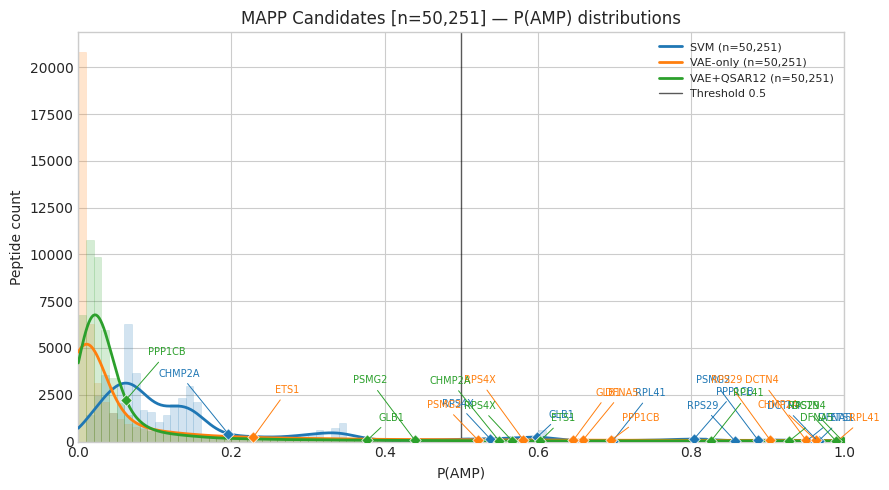

In [43]:
# P(AMP) distributions
comparison_result = load_comparison_result()
report_highlight_matches(comparison_result)
probability_entries = collect_suffix_entries(comparison_result, "_prob_AMP")
if not probability_entries:
    raise ValueError("No finite *_prob_AMP columns were found in the comparison CSV.")
probability_xlim = distribution_xlim(probability_entries, bounded=(0.0, 1.0))

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    probability_entries,
    f"{DATASET_NAME} — P(AMP) distributions",
    "P(AMP)",
    probability_xlim,
    threshold=0.5,
)
fig.tight_layout()
plt.show()


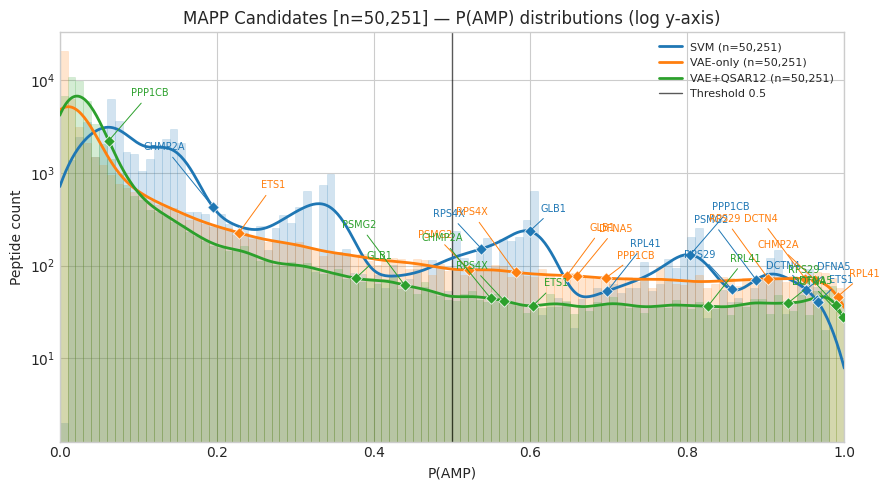

In [44]:
# P(AMP) distributions with a logarithmic count axis
if "probability_entries" not in globals():
    comparison_result = load_comparison_result()
    probability_entries = collect_suffix_entries(comparison_result, "_prob_AMP")
    probability_xlim = distribution_xlim(probability_entries, bounded=(0.0, 1.0))

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    probability_entries,
    f"{DATASET_NAME} — P(AMP) distributions (log y-axis)",
    "P(AMP)",
    probability_xlim,
    threshold=0.5,
    log_y=True,
)
fig.tight_layout()
plt.show()


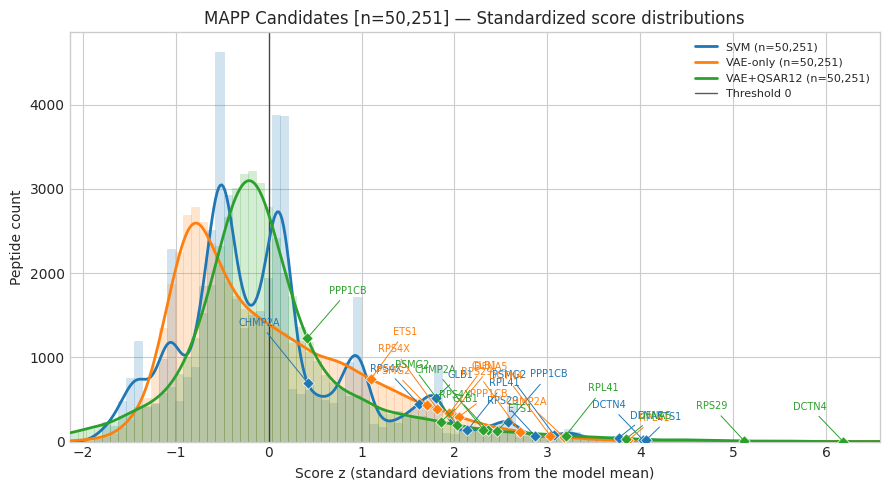

In [45]:
# Standardized score distributions
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()
standardized_entries = collect_suffix_entries(comparison_result, "_score_z")
if not standardized_entries:
    raise ValueError("No finite *_score_z columns were found in the comparison CSV.")

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    standardized_entries,
    f"{DATASET_NAME} — Standardized score distributions",
    "Score z (standard deviations from the model mean)",
    distribution_xlim(standardized_entries),
    threshold=0.0,
)
fig.tight_layout()
plt.show()


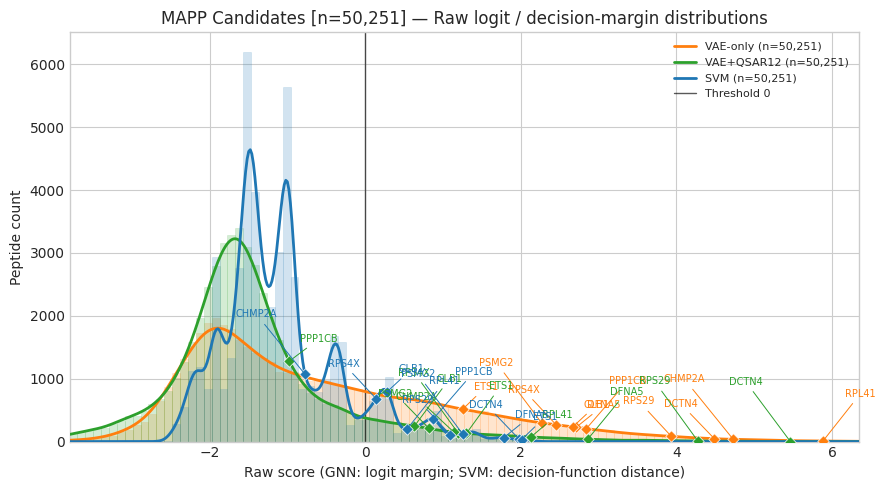

In [46]:
# Raw logit and decision-margin score distributions
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()
raw_score_entries = collect_raw_score_entries(comparison_result)
if not raw_score_entries:
    raise ValueError("No finite *_logit_margin or SVM distance columns were found.")

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    raw_score_entries,
    f"{DATASET_NAME} — Raw logit / decision-margin distributions",
    "Raw score (GNN: logit margin; SVM: decision-function distance)",
    distribution_xlim(raw_score_entries),
    threshold=0.0,
)
fig.tight_layout()
plt.show()


## Threshold Analysis

Showing only P(AMP) values from 0.90 to 1.00.


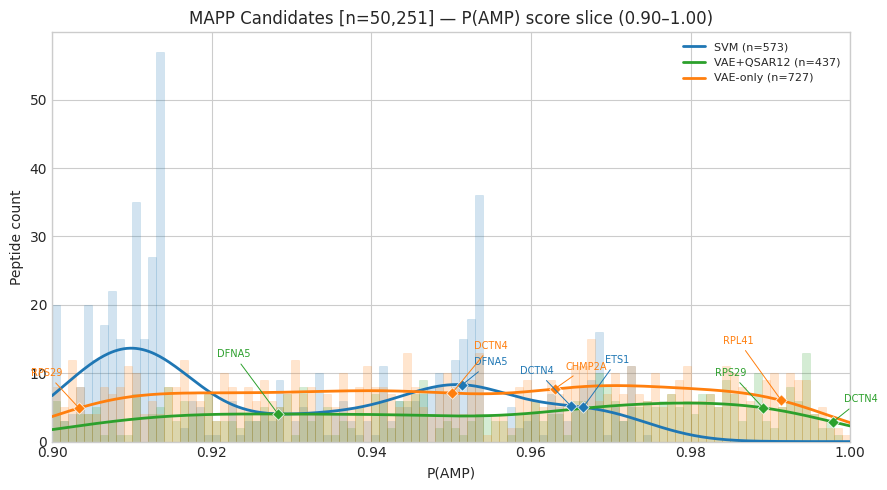

,Model,Candidates in slice,Labeled candidates in slice
0,SVM,573,3
1,VAE+QSAR12,437,3
2,VAE-only,727,4


In [47]:
# P(AMP) histograms showing only scores within the selected upper slice.
CANDIDATE_PLOT_THRESHOLD = 0.90

if not 0.0 <= CANDIDATE_PLOT_THRESHOLD <= 1.0:
    raise ValueError("CANDIDATE_PLOT_THRESHOLD must be between 0 and 1.")
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = sorted(c for c in frame.columns if c.endswith("_prob_AMP"))
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")
labeled_sequences = set(_highlight_labels())

# Each model contributes only its own scores inside the selected slice.
threshold_probability_entries = []
threshold_counts = []
for column in prob_columns:
    model = column[: -len("_prob_AMP")]
    probabilities = pd.to_numeric(frame[column], errors="coerce")
    passing_frame = frame.loc[probabilities.ge(CANDIDATE_PLOT_THRESHOLD)].copy()
    entry = _make_entry(
        {"path": comparison_result["path"], "frame": passing_frame},
        column,
        "_prob_AMP",
        model=model,
    )
    if entry is not None:
        threshold_probability_entries.append(entry)
    threshold_counts.append(
        {
            "Model": model,
            "Candidates in slice": len(passing_frame),
            "Labeled candidates in slice": passing_frame["__plot_sequence"].isin(
                labeled_sequences
            ).sum(),
        }
    )

if not threshold_probability_entries:
    raise ValueError(
        f"No P(AMP) values are ≥ {CANDIDATE_PLOT_THRESHOLD:.2f} in any model."
    )

# The full chart and its bins represent only this slice; no threshold line is drawn.
threshold_xlim = (CANDIDATE_PLOT_THRESHOLD, 1.0)
print(
    f"Showing only P(AMP) values from {CANDIDATE_PLOT_THRESHOLD:.2f} to 1.00."
)

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    threshold_probability_entries,
    f"{DATASET_NAME} — P(AMP) score slice ({CANDIDATE_PLOT_THRESHOLD:.2f}–1.00)",
    "P(AMP)",
    threshold_xlim,
)
fig.tight_layout()
plt.show()

threshold_candidate_counts = pd.DataFrame(threshold_counts)
display(threshold_candidate_counts)


In [48]:
# Labeled-sequence threshold summary
from IPython.display import display

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = sorted(c for c in frame.columns if c.endswith("_prob_AMP"))
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")

labeled_sequences = _highlight_labels()
if not labeled_sequences:
    raise ValueError("Add sequences to HIGHLIGHTED_SEQUENCES before running this summary.")

summary_rows = []
for normalized_sequence, label in labeled_sequences.items():
    matches = frame.loc[frame["__plot_sequence"] == normalized_sequence]
    if matches.empty:
        row = {
            "Label": label,
            "Sequence": normalized_sequence,
            "Status": "Missing from comparison CSV",
            "Included by any model": False,
        }
        for column in prob_columns:
            model = column[: -len("_prob_AMP")]
            row[f"{model} P(AMP)"] = np.nan
            row[f"{model} included"] = False
        summary_rows.append(row)
        continue

    for _, candidate in matches.iterrows():
        row = {
            "Label": label,
            "Sequence": normalized_sequence,
        }
        included_by_any = False
        for column in prob_columns:
            model = column[: -len("_prob_AMP")]
            score = pd.to_numeric(pd.Series([candidate[column]]), errors="coerce").iloc[0]
            included = bool(pd.notna(score) and score >= CANDIDATE_PLOT_THRESHOLD)
            row[f"{model} P(AMP)"] = score
            row[f"{model} included"] = included
            included_by_any |= included
        row["Included by any model"] = included_by_any
        row["Status"] = "Included" if included_by_any else "Excluded"
        summary_rows.append(row)

labeled_threshold_summary = pd.DataFrame(summary_rows)
status_order = {"Included": 0, "Excluded": 1, "Missing from comparison CSV": 2}
labeled_threshold_summary["__status_order"] = labeled_threshold_summary["Status"].map(status_order)
labeled_threshold_summary = labeled_threshold_summary.sort_values(
    ["__status_order", "Label"], kind="stable"
).drop(columns="__status_order")

status_counts = (
    labeled_threshold_summary["Status"]
    .value_counts()
    .reindex(["Included", "Excluded", "Missing from comparison CSV"], fill_value=0)
)
print(f"Labeled sequences at P(AMP) ≥ {CANDIDATE_PLOT_THRESHOLD:.2f}:")
print(f"  Included by at least one model: {status_counts['Included']}")
print(f"  Excluded by all models:         {status_counts['Excluded']}")
print(f"  Missing from comparison CSV:    {status_counts['Missing from comparison CSV']}")

display_columns = [
    column
    for column in labeled_threshold_summary.columns
    if column not in {"Sequence", "Included by any model", "Status"}
]
display(labeled_threshold_summary[display_columns])

copyable_labeled_threshold_summary = labeled_threshold_summary[display_columns].copy()
for column in copyable_labeled_threshold_summary.columns:
    if column.endswith("P(AMP)"):
        copyable_labeled_threshold_summary[column] = copyable_labeled_threshold_summary[column].map(
            lambda value: "" if pd.isna(value) else f"{value:.4f}"
        )
    elif column.endswith("included") or column == "Included by any model":
        copyable_labeled_threshold_summary[column] = copyable_labeled_threshold_summary[column].map(
            {True: "Yes", False: "No"}
        )

print("\nCopy/paste table:\n")
print(copyable_labeled_threshold_summary.to_string(index=False))


Labeled sequences at P(AMP) ≥ 0.90:
  Included by at least one model: 6
  Excluded by all models:         4
  Missing from comparison CSV:    0


,Label,SVM P(AMP),SVM included,VAE+QSAR12 P(AMP),VAE+QSAR12 included,VAE-only P(AMP),VAE-only included
7,CHMP2A,0.195501,False,0.549284,False,0.962974,True
1,DCTN4,0.964970,True,0.997850,True,0.950115,True
0,DFNA5,0.951418,True,0.928318,True,0.658790,False
8,ETS1,0.966555,True,0.602928,False,0.228267,False
2,RPL41,0.698040,False,0.826077,False,0.991378,True
9,RPS29,0.856899,False,0.989085,True,0.903373,True
4,GLB1,0.598922,False,0.377204,False,0.646360,False
6,PPP1CB,0.803675,False,0.062376,False,0.695762,False
3,PSMG2,0.887566,False,0.439557,False,0.521682,False
5,RPS4X,0.537567,False,0.566323,False,0.580968,False



Copy/paste table:

 Label SVM P(AMP) SVM included VAE+QSAR12 P(AMP) VAE+QSAR12 included VAE-only P(AMP) VAE-only included
CHMP2A     0.1955           No            0.5493                  No          0.9630               Yes
 DCTN4     0.9650          Yes            0.9978                 Yes          0.9501               Yes
 DFNA5     0.9514          Yes            0.9283                 Yes          0.6588                No
  ETS1     0.9666          Yes            0.6029                  No          0.2283                No
 RPL41     0.6980           No            0.8261                  No          0.9914               Yes
 RPS29     0.8569           No            0.9891                 Yes          0.9034               Yes
  GLB1     0.5989           No            0.3772                  No          0.6464                No
PPP1CB     0.8037           No            0.0624                  No          0.6958                No
 PSMG2     0.8876           No            0.4396     

## Summary analysis

Counts of peptides with **P(AMP) > 0.90** for the SVM and GNN predictions.


In [49]:
# P(AMP) distribution statistics (mean / median / mode / flat zeros)
from IPython.display import display

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = [c for c in frame.columns if c.endswith("_prob_AMP")]
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")


def _prob_amp_mode(values: np.ndarray, decimals: int = 4) -> tuple[float, int]:
    """Most frequent P(AMP) after rounding; ties keep the smallest value."""
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return float("nan"), 0
    rounded = np.round(finite.astype(float), decimals)
    uniq, counts = np.unique(rounded, return_counts=True)
    i = int(np.argmax(counts))
    return float(uniq[i]), int(counts[i])


stat_rows = []
for column in sorted(prob_columns):
    model = column[: -len("_prob_AMP")]
    probs = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=float)
    finite = probs[np.isfinite(probs)]
    n = int(finite.size)
    if n == 0:
        stat_rows.append({
            "Model": model,
            "N": 0,
            "Mean P(AMP)": np.nan,
            "Median P(AMP)": np.nan,
            "Mode P(AMP)": np.nan,
            "Mode count": 0,
            "Flat 0.0": 0,
            "% flat 0.0": np.nan,
        })
        continue
    mode_value, mode_count = _prob_amp_mode(finite)
    n_flat0 = int(np.sum(finite == 0.0))
    stat_rows.append({
        "Model": model,
        "N": n,
        "Mean P(AMP)": float(np.mean(finite)),
        "Median P(AMP)": float(np.median(finite)),
        "Mode P(AMP)": mode_value,
        "Mode count": mode_count,
        "Flat 0.0": n_flat0,
        "% flat 0.0": 100.0 * n_flat0 / n,
    })

prob_stats_table = pd.DataFrame(stat_rows)
copyable_prob_stats = prob_stats_table.copy()
for col in ("Mean P(AMP)", "Median P(AMP)", "Mode P(AMP)"):
    copyable_prob_stats[col] = copyable_prob_stats[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.4f}"
    )
copyable_prob_stats["% flat 0.0"] = copyable_prob_stats["% flat 0.0"].map(
    lambda x: "" if pd.isna(x) else f"{x:.1f}%"
)

display(copyable_prob_stats)
print(
    "Mode = most frequent P(AMP) after rounding to 4 decimals; "
    "Flat 0.0 = exact P(AMP) == 0.0.\n"
)
print("Copyable fixed-width table:\n")
print(
    f"{'Model':<18}{'N':>8}{'Mean':>10}{'Median':>10}"
    f"{'Mode':>10}{'Mode n':>8}{'Flat 0.0':>10}{'% flat 0':>10}"
)
for row in copyable_prob_stats.to_dict("records"):
    print(
        f"{row['Model']:<18}{row['N']:>8,d}{row['Mean P(AMP)']:>10}"
        f"{row['Median P(AMP)']:>10}{row['Mode P(AMP)']:>10}"
        f"{row['Mode count']:>8,d}{row['Flat 0.0']:>10,d}{row['% flat 0.0']:>10}"
    )


,Model,N,Mean P(AMP),Median P(AMP),Mode P(AMP),Mode count,Flat 0.0,% flat 0.0
0,SVM,50251,0.1767,0.1001,0.1524,551,0,0.0%
1,VAE+QSAR12,50251,0.0791,0.0273,0.0185,155,0,0.0%
2,VAE-only,50251,0.1098,0.0157,0.0035,380,0,0.0%


Mode = most frequent P(AMP) after rounding to 4 decimals; Flat 0.0 = exact P(AMP) == 0.0.

Copyable fixed-width table:

Model                    N      Mean    Median      Mode  Mode n  Flat 0.0  % flat 0
SVM                 50,251    0.1767    0.1001    0.1524     551         0      0.0%
VAE+QSAR12          50,251    0.0791    0.0273    0.0185     155         0      0.0%
VAE-only            50,251    0.1098    0.0157    0.0035     380         0      0.0%


In [54]:
from IPython.display import display

SUMMARY_THRESHOLD = 0.90

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

prob_columns = sorted([c for c in comparison_result["frame"].columns if c.endswith("_prob_AMP")])
summary_rows = []
for column in prob_columns:
    model = column[: -len("_prob_AMP")]
    probabilities = pd.to_numeric(comparison_result["frame"][column], errors="coerce")
    finite = probabilities.dropna()
    passing = int((finite > SUMMARY_THRESHOLD).sum())
    summary_rows.append({
        "Model": model,
        "Threshold": f"P(AMP) > {SUMMARY_THRESHOLD:.2f}",
        "Peptides passing": passing,
        "Finite predictions": len(finite),
        "Percent passing": 100.0 * passing / len(finite) if len(finite) else 0.0,
    })

summary_table = pd.DataFrame(summary_rows)
copyable_summary_table = summary_table.copy()
copyable_summary_table["Percent passing"] = copyable_summary_table["Percent passing"].map("{:.2f}%".format)

display(copyable_summary_table)
print("Copyable fixed-width table:\n")
print(
    f"{'Model':>12} {'Threshold':>16} {'Peptides passing':>18} "
    f"{'Finite predictions':>20} {'Percent passing':>16}"
)
for row in copyable_summary_table.to_dict("records"):
    print(
        f"{row['Model']:>12} {row['Threshold']:>16} {row['Peptides passing']:>18,d} "
        f"{row['Finite predictions']:>20,d} {row['Percent passing']:>16}"
    )


,Model,Threshold,Peptides passing,Finite predictions,Percent passing
0,SVM,P(AMP) > 0.90,573,50251,1.14%
1,VAE+QSAR12,P(AMP) > 0.90,437,50251,0.87%
2,VAE-only,P(AMP) > 0.90,727,50251,1.45%


Copyable fixed-width table:

       Model        Threshold   Peptides passing   Finite predictions  Percent passing
         SVM    P(AMP) > 0.90                573               50,251            1.14%
  VAE+QSAR12    P(AMP) > 0.90                437               50,251            0.87%
    VAE-only    P(AMP) > 0.90                727               50,251            1.45%
